In [1]:
import sys
import os
import glob
import pandas as pd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import struct


import funciones_aux as fau

import funciones_dsa as fun_dsa
import funciones_dsa_unilateral as fun_dsa_u
import funciones_dsa_bilateral as fun_dsa_b

import funciones_plot_dsa as fun_plot

from scipy.signal import welch
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from scipy.stats import pearsonr, spearmanr


# OG

#### Archivo f_a

In [2]:
ruta_base_advanced = "../data/data_bis_advanced"

archivos_fa = fau.localizar_archivos(ruta_base_advanced, "DH*", "*.f_a")
ruta_fa = archivos_fa[0]
print("Archivo seleccionado:", ruta_fa)

tiempo_fa_unilat, dsa_unilat = fau.cargar_fa_directo(ruta_fa, escalar_db=True)

print("Dimensiones de la matriz:", dsa_unilat.shape)
print("Frecuencias:", dsa_unilat.columns.min(), "a", dsa_unilat.columns.max(), "Hz")

Se han encontrado 2 archivos *.f_a
Archivo seleccionado: ../data/data_bis_advanced\M-TA6m-03041035\DH03041035\L03041035.f_a
Dimensiones de la matriz: (2119, 60)
Frecuencias: 0.5 a 30.0 Hz


#### Archivo spa

In [3]:
ruta_spa_unilat = "../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.spa"
df_spa_unilat = fau.procesar_spa(ruta_spa_unilat)

## Unión de los 2

In [4]:
df_merge_hor = fun_dsa.alinear_spa_con_tiempo(tiempo_fa_unilat, df_spa_unilat)
sef_hor = df_merge_hor["SEF08"]
mf_hor = df_merge_hor["MEDFRQ08"]

dsa_plot_hor, mask_total_hor = fun_dsa.preparar_dsa_para_plot(tiempo_fa_unilat, dsa_unilat, df_merge_hor)

# las matrices que vienen de la f_a suelen mostrar valores entre el 49 y 94
matriz_hor, vmin_hor, vmax_hor, norm_hor, cmap_hor = fun_dsa.preparar_escala_color_dsa(dsa_plot_hor, vmin=49, vmax=94, gamma=1)

In [5]:
cols_freq = [c for c in dsa_plot_hor.columns]


print(np.nanmin(dsa_plot_hor[cols_freq].values))
print(np.nanmax(dsa_plot_hor[cols_freq].values))

print(np.nanpercentile(dsa_plot_hor[cols_freq].values, 2))
print(np.nanpercentile(dsa_plot_hor[cols_freq].values, 99.5))

55.61
103.02
69.81
96.86205000000002


# Procesado

In [6]:
archivo_r2a = r"../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.r2a"

### Reconstrucción desde EEG crudo

In [7]:
df_eeg = fun_dsa_u.leer_r2a(
    archivo_r2a,
    fs=128,
    escala_uv=0.0511
)

# se pierde un segundo por el uso de ventanas de 2 segundos con etiqueta temporal en el centro
""" 
La función no calcula una DSA para cada muestra aislada ni para cada segundo independiente. 
Calcula una DSA por ventanas completas de 2 segundos (usando 256 muestras).
La ventana avanza cada segundo (cada 128 muestras).

Resultado: Cada fila de la DSA final no sale de un único segundo, sino de una ventana de 2 segundos.


Por eso, con ventanas de 2 segundos y paso de 1 segundo, si tienes un registro de N segundos, se obtienen aproximadamente:
N - 1 filas espectrales. 
No se obtienen N filas, porque no se puede calcular una ventana completa de 2 segundos centrada 
en todos los segundos extremos sin salirse del registro.
"""

df_dsa_canal1, frecuencias_c1 = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg,
    "canal_1_uV",
    fs=128,
    ventana_seg=2,
    paso_seg=1,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="centro"
)

df_dsa_canal2, _ = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg,
    "canal_2_uV",
    fs=128,
    ventana_seg=2,
    paso_seg=1,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="centro"
)

# columnas del dF generado después de la conversión por FFT -> las frecuencias
cols_freq = [c for c in df_dsa_canal1.columns if c != "tiempo_s"]

# copia del dF del canal 1 para tener esa estructura
df_dsa_media = df_dsa_canal1.copy()

# media (en float) de las potencias (en uV) de los 2 canales
# en función de las frecuencias 
pot_media = (
    df_dsa_canal1[cols_freq].to_numpy(dtype=float) +
    df_dsa_canal2[cols_freq].to_numpy(dtype=float)
) / 2

# array de los nombres de las columnas pasados a float
frecuencias_float = np.array([float(c) for c in cols_freq])

# calcular sef y mef solo para la dsa reconstruida del eeg 
# (basado en la potencia en uV)
sef_eeg, mef_eeg = fun_dsa.calcular_sef_mef_desde_potencia(
    potencia=pot_media,
    frecuencias=frecuencias_float,
    percentil_sef=0.95,
    percentil_mef=0.50
)

# Como después añadimos una fila inicial NaN a la DSA reconstruida,
# también añadimos un NaN inicial a SEF y MEF para que tengan la misma longitud.
sef_eeg_plot = pd.Series(
    np.r_[np.nan, sef_eeg],
    name="SEF08"
)

mef_eeg_plot = pd.Series(
    np.r_[np.nan, mef_eeg],
    name="MEDFRQ08"
)


# Conversión a dB usando la referencia documentada de la DSA BIS:
# 0.0001 µV RMS
ref_uv_rms = 0.0001

df_dsa_media[cols_freq] = 10 * np.log10(
    (pot_media + 1e-12) / (ref_uv_rms ** 2)
)

""" 
Desde aquí tenemos:
 - df_dsa_media: dataframe con la estructura de la dsa
     - cols_freq: los nombres de las columnas en string -> solo las frecuencias
     - el contenido de cada columna se sobreescribe con el resultado del cálculo
"""

' \nDesde aquí tenemos:\n - df_dsa_media: dataframe con la estructura de la dsa\n     - cols_freq: los nombres de las columnas en string -> solo las frecuencias\n     - el contenido de cada columna se sobreescribe con el resultado del cálculo\n'

In [8]:
print(np.nanmin(df_dsa_media[cols_freq].values))
print(np.nanmax(df_dsa_media[cols_freq].values))

print(np.nanpercentile(df_dsa_media[cols_freq].values, 2))
print(np.nanpercentile(df_dsa_media[cols_freq].values, 99.5))

43.8952330105952
134.55921182485093
73.38077366240869
117.33046386583177


### Adaptación temporal, máscara y plot de DSA EEG

In [9]:
df_spa_unilat, hora_inicio = fun_dsa.obtener_hora_inicio_desde_spa(
    df_spa_unilat
)

tiempo_eeg, dsa_eeg = fun_dsa.adaptar_dsa_reconstruida_para_plot(
    df_dsa=df_dsa_media,
    frecuencias=frecuencias_c1,
    hora_inicio=hora_inicio,
    insertar_fila_inicial_nan=True
)

df_merge_plot = fun_dsa.alinear_spa_con_tiempo(
    tiempo=tiempo_eeg,
    df_spa=df_spa_unilat
)

df_merge_plot["SEF08"] = sef_eeg_plot.values
df_merge_plot["MEDFRQ08"] = mef_eeg_plot.values

_, mask_total = fun_dsa.preparar_dsa_para_plot(
    tiempo=tiempo_eeg,
    dsa=dsa_eeg,
    df_merge=df_merge_plot,
    umbral_sqi=14,
    umbral_ceros=0.9
)

mask_comun = mask_total.copy()

# en las reconstrucciones se utilizan como valores mínimos y máximos 
# los percentiles más ajustados para replicar el color


In [10]:
# DSA original f_a con máscara común
dsa_fa_plot = dsa_unilat.copy()
dsa_fa_plot.loc[mask_comun.values, :] = np.nan

# DSA reconstruida directa con máscara común
dsa_eeg_directa_plot = dsa_eeg.copy()
dsa_eeg_directa_plot.loc[mask_comun.values, :] = np.nan

### Comprobar que ambas matrices están alineadas

In [11]:
print("DSA f_a:", dsa_fa_plot.shape)
print("DSA EEG:", dsa_eeg_directa_plot.shape)

print("¿Tiempos iguales?")
print((tiempo_fa_unilat.reset_index(drop=True) == tiempo_eeg.reset_index(drop=True)).all())

print("Rango DSA EEG reconstruida:")
print(np.nanmin(dsa_eeg_directa_plot.values), np.nanmax(dsa_eeg_directa_plot.values))

print("Rango DSA f_a:")
print(np.nanmin(dsa_fa_plot.values), np.nanmax(dsa_fa_plot.values))

DSA f_a: (2119, 60)
DSA EEG: (2119, 60)
¿Tiempos iguales?
True
Rango DSA EEG reconstruida:
43.8952330105952 131.9917827205913
Rango DSA f_a:
55.61 103.02


## Preparar escalas de color de f_a y EEG directa

In [12]:
matriz_fa, vmin_fa, vmax_fa, norm_fa, cmap_fa = fun_dsa.preparar_escala_color_dsa(
    dsa_fa_plot,
    vmin=49,
    vmax=94,
    gamma=1
)

matriz_eeg, vmin_eeg, vmax_eeg, norm_eeg, cmap_eeg = fun_dsa.preparar_escala_color_dsa(
    dsa_eeg_directa_plot,
    gamma=0.4
)

### Comparación base

In [13]:
dsa_eeg_comparacion, dsa_fa_comparacion = fun_dsa.preparar_matrices_para_comparacion(
    dsa_eeg_directa_plot,
    dsa_fa_plot
)

dsa_eeg_z = fun_dsa.zscore_global(dsa_eeg_comparacion)
dsa_fa_z = fun_dsa.zscore_global(dsa_fa_comparacion)

metricas_base = fun_dsa.comparar_dsa_global(
    dsa_eeg_z,
    dsa_fa_z
)

metricas_base

{'n_valores_comparados': 120360,
 'MAE': np.float64(0.853449991881016),
 'RMSE': np.float64(1.0999045923442847),
 'bias_B_menos_A': np.float64(2.7297687023551872e-15),
 'Pearson': np.float64(0.3951049438699764),
 'Spearman': np.float64(0.31501497963394975)}

### Correlación por frecuencia

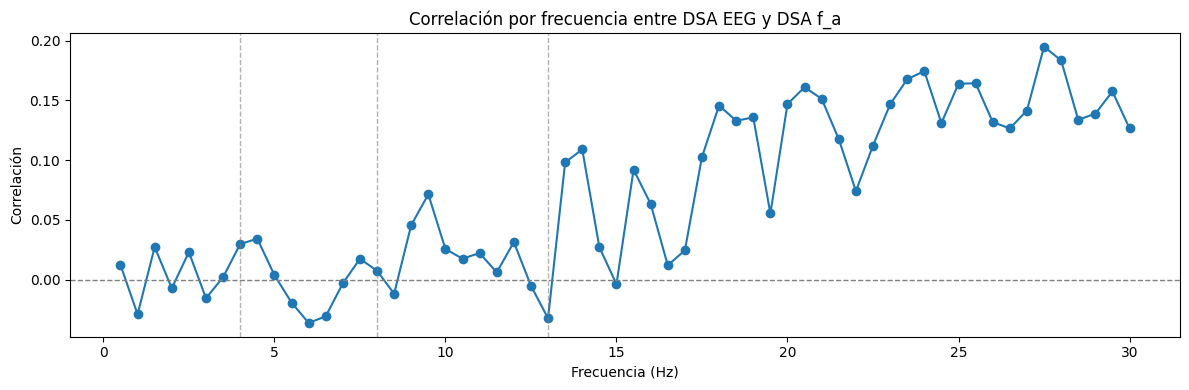

In [14]:
df_corr_freq = fun_dsa.correlacion_por_frecuencia(
    dsa_eeg_z,
    dsa_fa_z
)

plt.figure(figsize=(12, 4))

plt.plot(
    df_corr_freq["frecuencia_Hz"],
    df_corr_freq["correlacion"],
    marker="o"
)

for f in [4, 8, 13]:
    plt.axvline(f, color="gray", linestyle="--", linewidth=1, alpha=0.6)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)

plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Correlación")
plt.title("Correlación por frecuencia entre DSA EEG y DSA f_a")
plt.tight_layout()
plt.show()

### Suavizado temporal

Suavizado temporal de la DSA reconstruida desde EEG

La DSA reconstruida desde el EEG crudo viene de un cálculo directo y produce una DSA con muchos cambios rápidos. 

La DSA del f_a del BIS se ve más suave y no cambia tan bruscamente de segundo a segundo. Sugiere que el BIS podría aplicar algún tipo de promedio temporal interno antes de guardar el f_a.

### Suavizado + shift

In [15]:
ventanas_sp_smooth = [5, 10, 30, 60]

df_suav_shift = fun_dsa.probar_suavizado_y_shifts(
    dsa_eeg_comparacion,
    dsa_fa_comparacion,
    ventanas_suavizado=ventanas_sp_smooth,
    shifts=range(-60, 61)
)

df_suav_shift.sort_values("Pearson", ascending=False).head(7)

,suavizado_s,shift_s,Pearson,Spearman,MAE,RMSE
313,30,11,0.717024,0.713138,0.559875,0.749870
312,30,10,0.716746,0.713673,0.559463,0.750319
314,30,12,0.716392,0.711372,0.561305,0.750640
311,30,9,0.715592,0.712957,0.560037,0.751956
315,30,13,0.714884,0.708324,0.563714,0.752586
310,30,8,0.713694,0.710981,0.561567,0.754561
316,30,14,0.712610,0.704089,0.567009,0.755528


In [16]:
df_suav_shift.sort_values("Spearman", ascending=False).head(7)

,suavizado_s,shift_s,Pearson,Spearman,MAE,RMSE
312,30,10,0.716746,0.713673,0.559463,0.750319
313,30,11,0.717024,0.713138,0.559875,0.749870
311,30,9,0.715592,0.712957,0.560037,0.751956
314,30,12,0.716392,0.711372,0.561305,0.750640
310,30,8,0.713694,0.710981,0.561567,0.754561
315,30,13,0.714884,0.708324,0.563714,0.752586
309,30,7,0.711000,0.707805,0.564062,0.758184


### Tabla resumen final

La variante que mejor aproximó la DSA reconstruida desde EEG crudo a la DSA del archivo `f_a` fue la media de potencias de los dos canales, calculada a partir de densidad espectral de potencia y convertida posteriormente a dB. 

Tras aplicar un suavizado temporal causal de 25 s y un desplazamiento temporal de 13 s, se obtuvo una correlación de Pearson de aproximadamente 0.706 y una correlación de Spearman de aproximadamente 0.704. 

Esto sugiere que el archivo `f_a` incorpora información espectral de ambos canales, así como procesamiento temporal suavizado y un posible retardo asociado al cálculo interno del monitor BIS.

In [17]:
mejor_pearson = df_suav_shift.sort_values("Pearson", ascending=False).iloc[0]
mejor_spearman = df_suav_shift.sort_values("Spearman", ascending=False).iloc[0]

df_resumen_final = pd.DataFrame([
    {
        "criterio": "Mejor Pearson",
        "suavizado_s": mejor_pearson["suavizado_s"],
        "shift_s": mejor_pearson["shift_s"],
        "Pearson": mejor_pearson["Pearson"],
        "Spearman": mejor_pearson["Spearman"],
        "MAE": mejor_pearson["MAE"],
        "RMSE": mejor_pearson["RMSE"],
    },
    {
        "criterio": "Mejor Spearman",
        "suavizado_s": mejor_spearman["suavizado_s"],
        "shift_s": mejor_spearman["shift_s"],
        "Pearson": mejor_spearman["Pearson"],
        "Spearman": mejor_spearman["Spearman"],
        "MAE": mejor_spearman["MAE"],
        "RMSE": mejor_spearman["RMSE"],
    }
])

df_resumen_final

,criterio,suavizado_s,shift_s,Pearson,Spearman,MAE,RMSE
0,Mejor Pearson,30.0,11.0,0.717024,0.713138,0.559875,0.749870
1,Mejor Spearman,30.0,10.0,0.716746,0.713673,0.559463,0.750319


## Comparación entre la DSA reconstruida desde EEG crudo y la DSA exportada por el BIS

El objetivo de este bloque es evaluar de forma objetiva la similitud entre la matriz tiempo-frecuencia obtenida desde el EEG crudo y la matriz exportada por el monitor BIS.

Se ha desarrollado un sistema comparador para evaluar la similitud entre la DSA reconstruida desde el EEG crudo y la DSA contenida en el archivo .f_a.

Este sistema compara ambas matrices tanto visual como cuantitativamente. 
Para ello:
 - Las matrices se alinean temporal y frecuencialmente
 - Se eliminan los tramos no válidos mediante una máscara común
 - Se nrmalizan mediante el z - score para compensar diferencias de escala
 - Se calculan métricas de similitud: Correlación de Pearson, Correlación de Spearman, MAE y RMSE.
 
Además, el sistema ha permitido evaluar variantes de procesamiento, como el suavizado temporal, para determinar qué configuración reproduce mejor la matriz construida a partir del archivo .f_a.

------------------------------------------------------------------------------------------------
### Cambio de los colores en la figura final y funcionamiento del z-score

En la figura comparativa final, los colores no representan los valores absolutos originales de cada matriz, sino valores normalizados mediante el z-score. 

Esta normalización transforma cada celda según su desviación respecto a la media global de su propia matriz. Por tanto, los colores indican si una región presenta una intensidad relativamente alta o baja dentro de cada DSA. 

Al emplear una escala común para las tres matrices normalizadas, la figura permite comparar patrones relativos, aunque el aspecto cromático difiera del observado en las tres representaciones individuales.

$$
Z(t,f)=\frac{D(t,f)-\mu_D}{\sigma_D}
$$

Donde: 
 - D(t,f) es el valor de la DSA en el instante \(t\) 
 - la frecuencia \(f\)
 - $\mu_D$ es la media global de la matriz 
 - $\sigma_D$ su desviación típica.


#### Afectación del suavizado temporal a los tramos no válidos

Las bandas blancas tepresentan tramos no válidos o pérdida de información. Al aplicar un suavizado temporal mediante la media móvil, algunos valores NaN quedaban reemplazados por promedios de valores válidos cercanos.

Esto provoca que ciertas bandas blancas desaparezcan en la DSA optimizada, aunque sigan correspondiendo a tramos de señal no válida. Para evitarlo, se volvió a aplicar la máscara de pérdida de información después del suavizado y del desplazamiento temporal. De este modo, las zonas no válidas permanecen blancas en todas las matrices comparadas.

Las bandas blancas de la DSA optimizada no tienen por qué coincidir exactamente con las de la DSA reconstruida sin desplazar, porque la versión optimizada ha sido desplazada temporalmente. Lo importante es que la máscara de validez se aplique de forma consistente con el mismo recorte y desplazamiento que se usa para comparar las matrices.


### Shift temporal

Aunque ambas matrices estaban alineadas por marca temporal, el cálculo interno del monitor puede introducir un retardo efectivo debido al uso de ventanas temporales, promediado o procesamiento acumulativo.

Por ello se evaluaron desplazamientos temporales entre matrices. El desplazamiento no se aplicó para modificar la señal reconstruida original, sino para estimar qué desfase proporcionaba la mayor correspondencia con la matriz f_a.

La mejor similitud se obtuvo con un suavizado causal de 25 segundos y un desplazamiento de 13 segundos, lo que sugiere que la DSA del f_a podría incorporar procesamiento temporal acumulado y cierto retardo respecto a la estimación espectral instantánea.


### Media de potencia de los dos canales

La señal r2a contiene dos canales EEG. Se evaluaron reconstrucciones usando canal 1, canal 2 y una combinación de ambos.

La mejor similitud se obtuvo al promediar las densidades espectrales de potencia de ambos canales en escala lineal y convertir posteriormente a dB.

Esta estrategia es preferible a promediar directamente los dB, ya que la escala logarítmica no es lineal. El resultado sugiere que la DSA del f_a podría incorporar información espectral procedente de ambos canales.

$$
P_{\text{media}}(t,f)=\frac{P_1(t,f)+P_2(t,f)}{2}
$$

$$
D_{\text{media}}(t,f)=10\log_{10}\left(P_{\text{media}}(t,f)\right)
$$

-----------------------------------------------------------------------------------------------

El sistema es un comparador porque no solo genera una imagen:
- alinea las matrices;
- aplica una máscara de validez común;
- normaliza las escalas;
- calcula correlaciones y errores;
- permite probar variantes de reconstrucción;
- identifica la configuración que maximiza la similitud;
- muestra una comparación visual final.

## Suavizado limpio

In [18]:
suavizado_final = 30
shift_final = 10

# Suavizado sobre DSA base, SIN máscara
dsa_eeg_suav = dsa_eeg.copy().rolling(
    window=suavizado_final,
    min_periods=1,
    center=False
).mean()

# Aplicar máscara común al final
dsa_eeg_suav_plot = dsa_eeg_suav.copy()
dsa_eeg_suav_plot.loc[mask_comun.values, :] = np.nan

matriz_opt, vmin_opt, vmax_opt, norm_opt, cmap_opt = fun_dsa.preparar_escala_color_dsa(
    dsa_eeg_suav_plot,
    gamma=0.25
)

## Suavizada + shift

In [28]:
dsa_eeg_suav_shift = dsa_eeg_suav.iloc[:-shift_final].reset_index(drop=True)
tiempo_opt_desfase = tiempo_eeg.iloc[shift_final:].reset_index(drop=True)

df_merge_opt_desfase = df_merge_plot.iloc[shift_final:].reset_index(drop=True)
mask_comun_desfase = mask_comun.iloc[shift_final:].reset_index(drop=True)

dsa_eeg_suav_shift_plot = dsa_eeg_suav_shift.copy()
dsa_eeg_suav_shift_plot.loc[mask_comun_desfase.values, :] = np.nan

matriz_opt_desfase, vmin_opt_desfase, vmax_opt_desfase, norm_opt_desfase, cmap_opt_desfase = fun_dsa.preparar_escala_color_dsa(
    dsa_eeg_suav_shift_plot,
    gamma=0.25
)

## Comprobación de bandas blancas

In [20]:
mask_blanca_directa = dsa_eeg_directa_plot.isna().all(axis=1)
mask_blanca_suav = dsa_eeg_suav_plot.isna().all(axis=1)

print("¿Coinciden bandas blancas directa vs suavizada?")
print((mask_blanca_directa == mask_blanca_suav).all())

print("Diferencias:")
print((mask_blanca_directa != mask_blanca_suav).sum())

¿Coinciden bandas blancas directa vs suavizada?
True
Diferencias:
0


# COMPARACIÓN FINAL

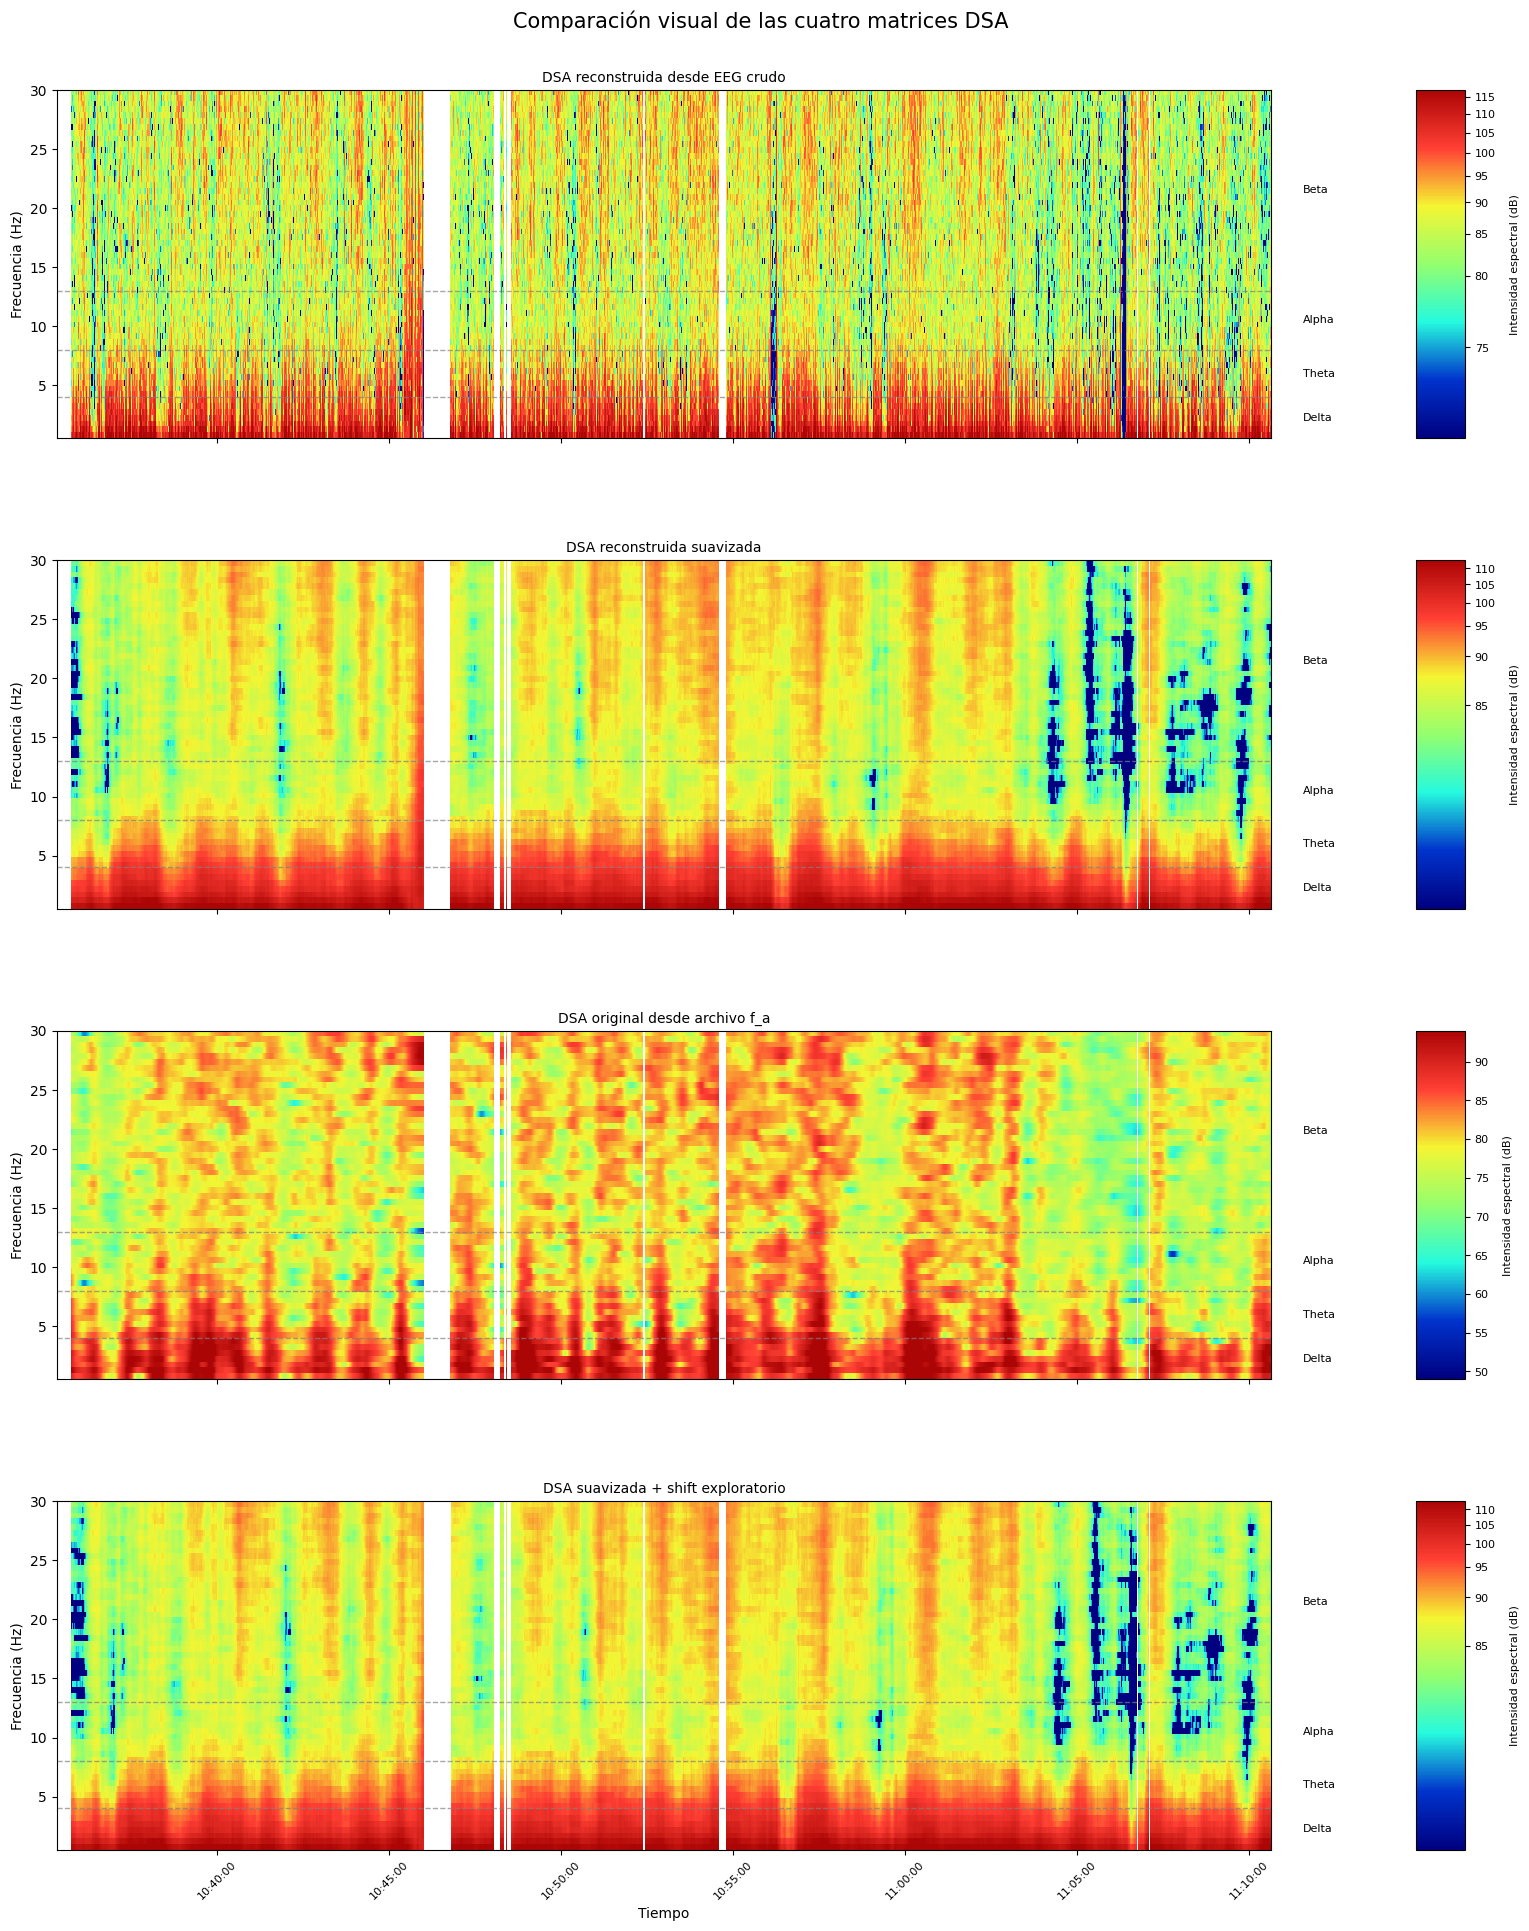

In [30]:
paneles = [
    
    {
        "tiempo": tiempo_eeg,
        "frecuencias": frecuencias_c1,
        "matriz": matriz_eeg,
        "norm": norm_eeg,
        "cmap": cmap_eeg,
        "df_merge": df_merge_plot,
        "titulo": "DSA reconstruida desde EEG crudo",
        "etiqueta_colorbar": "Intensidad espectral (dB)",
        "mask_total": mask_comun
    },
    {
        "tiempo": tiempo_eeg,
        "frecuencias": frecuencias_c1,
        "matriz": matriz_opt,
        "norm": norm_opt,
        "cmap": cmap_opt,
        "df_merge": df_merge_plot,
        "titulo": "DSA reconstruida suavizada",
        "etiqueta_colorbar": "Intensidad espectral (dB)",
        "mask_total": mask_comun
    },
    {
        "tiempo": tiempo_fa_unilat,
        "frecuencias": dsa_fa_plot.columns.astype(float),
        "matriz": matriz_fa,
        "norm": norm_fa,
        "cmap": cmap_fa,
        "df_merge": df_merge_hor,
        "titulo": "DSA original desde archivo f_a",
        "etiqueta_colorbar": "Intensidad espectral (dB)",
        "mask_total": mask_comun
    },
    {
        "tiempo": tiempo_opt_desfase,
        "frecuencias": frecuencias_c1,
        "matriz": matriz_opt_desfase,
        "norm": norm_opt_desfase,
        "cmap": cmap_opt_desfase,
        "df_merge": df_merge_opt_desfase,
        "titulo": "DSA suavizada + shift exploratorio",
        "etiqueta_colorbar": "Intensidad espectral (dB)",
        "mask_total": mask_comun_desfase
    }
]

fig_grid, axes_grid = fun_dsa.plot_cuadricula_4_dsa(
    paneles,
    titulo_general="Comparación visual de las cuatro matrices DSA"
)

In [23]:
for i, (ax, ax_band, cax) in enumerate(axes_grid, start=1):
    print(f"Panel {i}")
    print("posición DSA:", ax.get_position().bounds)
    print("xlim:", ax.get_xlim())
    print()

Panel 1
posición DSA: (np.float64(0.06), np.float64(0.7657425742574258), np.float64(0.7588823732321488), np.float64(0.1742574257425742))
xlim: (np.float64(20516.441215277777), np.float64(20516.465729166666))

Panel 2
posición DSA: (np.float64(0.06), np.float64(0.5304950495049505), np.float64(0.7588823732321488), np.float64(0.1742574257425742))
xlim: (np.float64(20516.441215277777), np.float64(20516.465729166666))

Panel 3
posición DSA: (np.float64(0.06), np.float64(0.2952475247524753), np.float64(0.7588823732321488), np.float64(0.1742574257425742))
xlim: (np.float64(20516.441215277777), np.float64(20516.465729166666))

Panel 4
posición DSA: (np.float64(0.06), np.float64(0.06000000000000005), np.float64(0.7588823732321488), np.float64(0.1742574257425743))
xlim: (np.float64(20516.441215277777), np.float64(20516.465729166666))



### Descripción de las figuras (de izquierda a derecha y arriba abajo)

**DSA original desde f_a:**

Matriz de Densidad Espectral de referencia. Es la obtenida a partir de los archivos exportados del BIS sin ningún procesado además del que pueda incorporar el propio monitor BIS.
Tiene una textura relativamente suavizada con cambios temporales "gruesos", no tan abruptos segundo a segundo.


**DSA reconstruida desde EEG crudo:**

Matriz de Densidad Espectral reconstruida partiendo de la amplitud de las ondas originales del EEG. Esta reconstrucción directa tiene mucha variabilidad rápida, muchas bandas verticales finas y una textura más ruidosa. Al ser una estimación espectral directa, dista un poco de la DSA original ya que carece del suavizado/procesamiento interno que aplica el BIS.


**DSA reconstruida optimizada/suavizada:**

Para paliar los efectos del ruido de la matriz anterior, se le aplica un suavizado temporal causal. Esta matriz se parece bastante más a la del f_a. El suavizado reduce el rayado vertical y hace que aparezcan estructuras temporales más parecidas a la DSA original.
Es la DSA resultante de una reconstrucción postprocesadasin forzar demasiado la alineación temporal.


**DSA optimizada para validación: suavizado + shift**

Aunque ambas matrices estaban alineadas por marca temporal, el cálculo interno del monitor puede introducir un retardo efectivo debido al uso de ventanas temporales, promediado o procesamiento acumulativo.
Esta matriz es la que más se acerca visualmente al f_a en cuanto a estructura global y localización de patrones. 


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def comparar_dsa_mismo_eje(
    tiempo,
    frecuencias,
    matriz_1,
    matriz_2,
    norm_1,
    norm_2,
    cmap_1,
    cmap_2,
    titulo_1="DSA original f_a",
    titulo_2="DSA reconstruida suavizada"
):
    frecuencias = np.asarray(frecuencias_c1, dtype=float)

    x0 = mdates.date2num(tiempo.iloc[0])
    x1 = mdates.date2num(tiempo.iloc[-1])

    y0 = np.min(frecuencias)
    y1 = np.max(frecuencias)

    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(18, 8),
        sharex=True,
        sharey=True,
        constrained_layout=True
    )

    im1 = axes[0].imshow(
        matriz_1.T,
        aspect="auto",
        origin="lower",
        extent=[x0, x1, y0, y1],
        cmap=cmap_1,
        norm=norm_1,
        interpolation="nearest"
    )

    im2 = axes[1].imshow(
        matriz_2.T,
        aspect="auto",
        origin="lower",
        extent=[x0, x1, y0, y1],
        cmap=cmap_2,
        norm=norm_2,
        interpolation="nearest"
    )

    axes[0].set_title(titulo_1)
    axes[1].set_title(titulo_2)

    for ax in axes:
        ax.set_ylabel("Frecuencia (Hz)")
        ax.set_ylim(y0, y1)

        for f in [4, 8, 13]:
            ax.axhline(
                f,
                color="gray",
                linestyle="--",
                linewidth=1,
                alpha=0.7
            )

    axes[1].set_xlabel("Tiempo")
    axes[1].xaxis_date()
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    plt.setp(axes[1].get_xticklabels(), rotation=45)

    fig.colorbar(im1, ax=axes[0], pad=0.01, label="Intensidad espectral (dB)")
    fig.colorbar(im2, ax=axes[1], pad=0.01, label="Intensidad espectral (dB)")

    plt.show()

    return fig, axes

In [ ]:
fig_comp, axes_comp = comparar_dsa_mismo_eje(
    tiempo=tiempo_fa_unilat,
    frecuencias=frecuencias_c1,
    matriz_1=matriz_hor,
    matriz_2=matriz_opt_desfase,
    norm_1=norm_hor,
    norm_2=norm_opt,
    cmap_1=cmap_hor,
    cmap_2=cmap_opt,
    titulo_1="DSA original desde archivo f_a",
    titulo_2="DSA reconstruida suavizada"
)

In [ ]:
print("posición 1:", axes_comp[0].get_position().bounds)
print(f"\nposición 2:", axes_comp[1].get_position().bounds)
print(f"\nxlim 1:", axes_comp[0].get_xlim())
print(f"\nxlim 2:", axes_comp[1].get_xlim())

In [ ]:
mask_comun = fun_dsa.construir_mascara_no_valida(df_merge_plot, umbral_sqi=14)


In [ ]:
# dsa original f_a
dsa_fa_plot = dsa_unilat.copy()
dsa_fa_plot.loc[mask_comun.values, :] = np.nan

In [ ]:
# dsa reconstruida directa
dsa_eeg_directa_plot = dsa_eeg.copy()
dsa_eeg_directa_plot.loc[mask_comun.values, :] = np.nan

In [ ]:
# dsa suavizada
dsa_eeg_suav = dsa_eeg.copy().rolling(
    window=30,
    min_periods=1,
    center=False
).mean()

dsa_eeg_suav_plot = dsa_eeg_suav.copy()
dsa_eeg_suav_plot.loc[mask_comun.values, :] = np.nan

In [ ]:
# dsa suavizada con shift
shift_final = 10  # o el valor que estés usando

dsa_eeg_suav_shift = dsa_eeg_suav.iloc[:-shift_final].reset_index(drop=True)
tiempo_shift = tiempo_eeg.iloc[shift_final:].reset_index(drop=True)

mask_comun_shift = mask_comun.iloc[shift_final:].reset_index(drop=True)

dsa_eeg_suav_shift_plot = dsa_eeg_suav_shift.copy()
dsa_eeg_suav_shift_plot.loc[mask_comun_shift.values, :] = np.nan

In [ ]:
mask_blanca_directa = dsa_eeg_directa_plot.isna().all(axis=1)
mask_blanca_suav = dsa_eeg_suav_plot.isna().all(axis=1)

print("¿Coinciden bandas blancas directa vs suavizada?")
print((mask_blanca_directa == mask_blanca_suav).all())

print("Diferencias:")
print((mask_blanca_directa != mask_blanca_suav).sum())